In [1]:
format short g

In [2]:
pkg install "https://github.com/gnu-octave/statistics-resampling/archive/refs/heads/master.zip"

The statistics-resampling package was installed into the directory:
/home/jovyan/.local/share/octave/api-v58/packages/statistics-resampling-5.6.1-dev
License and copyright information can be found at:
https://github.com/gnu-octave/statistics-resampling/blob/master/COPYING


In [3]:
pkg load statistics-resampling

In [4]:
[~, genotype] = xlsread ('../data/abeta-cleaned-ver2.xlsx', 'abeta', 'E2:E165');
[~, condition] = xlsread ('../data/abeta-cleaned-ver2.xlsx', 'abeta', 'F2:F165');

% for cell clusters am I averaging from the same cell into one data point
% need to load animal information once it is available

outcomes = xlsread ('../data/abeta-cleaned-ver2.xlsx', 'abeta', 'G2:S165');

disp (size(genotype))
disp (size(condition))
disp (size(outcomes))

          164            1
          164            1
          164           13


In [6]:
% getting rid of columns now as matrix automatically removes NaN, remember that now means that the outcome numbers have shifted 

In [7]:
if (size(outcomes, 2) > 11)
    outcomes(:,[8,13]) = [];
end

disp (size(outcomes))

          164           11


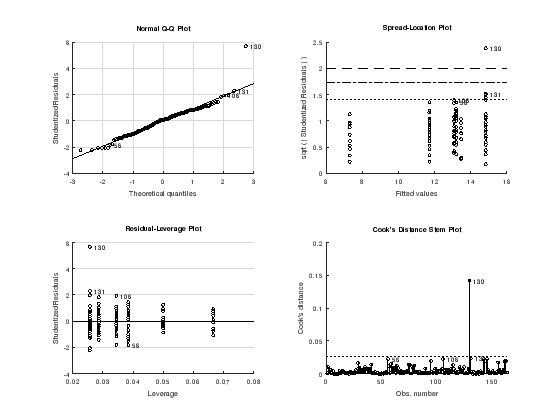

In [8]:
for i = 1: size(outcomes, 2)
    MAT_T = bootlm (outcomes(:,i), {genotype, condition}, 'model', 'full', 'display', 'on', ...
            'contrasts', 'treatment', 'nboot', 0);
    print(sprintf('../output/NC_ver2/outcome%d.png', i), '-dpng', '-r300')
end


In [9]:
% after looking at graphs, outlier rows are: row 2 (outcome 7)  row 130 (outcome 11) (double check)

In [10]:
if (size (outcomes, 1) > 162)
    genotype([2,130],:) = [];
    condition([2,130],:) = [];
    outcomes([2,130],:) = [];
    MAT_T.X([2,130],:) = [];
end

disp (size(genotype))
disp (size(condition))
disp (size(outcomes))
disp (size(MAT_T.X))

          162            1
          162            1
          162           11
          162            6


In [11]:
% bayesian bootstrap summary statistics using Simple Random Sampling

In [12]:
STATS_SRS = bootbayes(outcomes, MAT_T.X);

In [13]:
% can't do cluster bootstrap sampling as of yet, assume Deff = 1

In [14]:
Deff = 1

Deff =     1


In [15]:
% orthogonal (helmert) contrast coding

In [16]:
MAT_H = bootlm (outcomes(:,11), {genotype,condition}, 'model', 'full', ...
                'display', 'off', 'contrasts', 'helmert', 'nboot', 0, 'dim', [1,2]);
MAT_H.C

MAT_H = bootlm (outcomes(:,11), {genotype, condition}, 'model', 'full', ...
                'display', 'off', 'contrasts', MAT_H.C, 'nboot', 0, 'dim', [1,2]);
                
size (MAT_H.X)

ans =
{
  [1,1] =

           -0.5
            0.5

  [1,2] =

       -0.66667            0
        0.33333         -0.5
        0.33333          0.5

}

ans =

          196            6



In [17]:
% fitting model using ridge regression


 Empirical Bayes Ridge Regression (.632 Bootstrap Tuning) - Summary
 *******************************************************************************

 Number of predictors (p): 5

 Number of outcomes (q): 11

 Sample size: 196

 Design effect (Deff): 1

 Bootstrap resamples (nboot): 1999

 Minimized .632 bootstrap prediction error: 9.17345

 Predicted R-squared: 0.166 (16.6%)

 Bootstrap optimized ridge tuning constant (lambda): 4.09258

 Effective residual degrees of freedom (df_lambda): 191.

 Residual variances (range): [0.0361, 5e+03]

 Inferential degrees of freedom (df_t): 191.
 Used for credible intervals and Bayes factors below.

 95% credible intervals for correlations between outcomes:
 (Prior on Fisher's z is flat/improper)

 Outcome J     Outcome I     correlation   CI_lower      CI_upper     
 1             2             +0.2103       +0.06988      +0.3426  
 1             3             +0.6805       +0.5957       +0.7502  
 1             4             +0.1715       +0.02

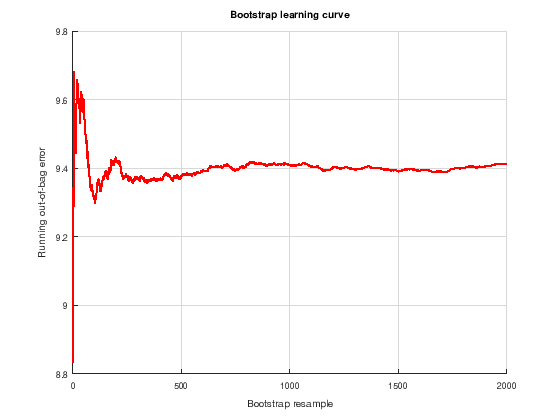

In [18]:
tic
bootridge(outcomes, MAT_H.X, '*', 1999, 0.05, [], Deff);
toc
ridge_coeff = ans;

In [19]:
% stability selection, rate has to be 97.5

In [20]:
disp (ridge_coeff.stability*100)

 Columns 1 through 6:

          NaN          NaN          NaN          NaN          NaN          NaN
       99.875       99.675       99.925       89.675       99.875       99.975
       99.975       98.625       94.425       99.975       99.975       99.975
       99.975       98.375       99.975       99.075       97.625       99.175
       99.975       69.275       99.775       77.675       51.275       75.875
       96.575       99.875       99.975       99.725       94.575       94.775

 Columns 7 through 11:

          NaN          NaN          NaN          NaN          NaN
       99.975       89.875       99.975       94.625       99.875
       99.975       99.975       63.675       89.425       99.975
       75.725       55.075       96.525       94.475       65.025
       90.575       87.425       93.475       52.225       99.725
       60.525       57.575       86.575       95.625       73.425


In [21]:
ridge_coeff.BF10

ans =

 Columns 1 through 6:

          NaN          NaN          NaN          NaN          NaN          NaN
       10.963       4.1155       24.642      0.52985       8.3064       1847.1
        13377        1.894      0.69063       82.003       4228.5   8.2072e+05
        714.7       1.7411        12520       2.6321       2.2824       3.0796
       67.717       0.5605       4.9069      0.61294      0.52156      0.61523
        2.151       5.2624        30.94       5.2453       1.3468       1.2175

 Columns 7 through 11:

          NaN          NaN          NaN          NaN          NaN
   1.0522e+10      0.59499        16434      0.96973       9.2007
   3.7878e+10   1.3968e+05      0.30449      0.56705       2730.9
      0.42628       0.3647       1.9878      0.91528      0.38971
      0.86401      0.99002      0.99124      0.52201       3.9389
      0.62951      0.62386      0.89445       1.6052      0.68729



In [22]:
reminder- 
1. intercept, represnts grand mean
2. G2 - G1 averaged over conditions
3. C5C6 - C4 averaged over genotypes
4. C6 - C5 averaged over genotypes
5. is [G2 -G1] different in C5C6 compared to C4
6. is [G2 -G1] different in C6 compared to C5

error: parse error:

  syntax error

>>> reminder- 
             ^
error: parse error:

  syntax error

>>> 1. intercept, represnts grand mean
               ^
error: parse error:

  syntax error

>>> 2. G2 - G1 averaged over conditions
        ^
error: parse error:

  syntax error

>>> 3. C5C6 - C4 averaged over genotypes
          ^
error: parse error:

  syntax error

>>> 4. C6 - C5 averaged over genotypes
        ^
error: parse error:

  syntax error

>>> 5. is [G2 -G1] different in C5C6 compared to C4
        ^
error: parse error:

  syntax error

>>> 6. is [G2 -G1] different in C6 compared to C5
        ^


In [23]:
outcome numbers now corresponds to (after removing 8 and 13) : 
1. peak
2. afterhyp
3. amp 
4. thresh
5. half (full-width at half maximum)
6. rise 
7. fall 
8. rheobase (current it takes to reach thresh)
9. sag (IH sag)
10. RMP (resting membrane potential)
11. maxApnum

error: 'outcome' undefined near line 1, column 1
error: parse error:

  syntax error

>>> 1. peak
          ^
error: parse error:

  syntax error

>>> 2. afterhyp
              ^
error: parse error:

  syntax error

>>> 3. amp 
         ^
error: parse error:

  syntax error

>>> 4. thresh
            ^
error: parse error:

  syntax error

>>> 5. half (full-width at half maximum)
          ^
error: parse error:

  syntax error

>>> 6. rise 
          ^
error: parse error:

  syntax error

>>> 7. fall 
          ^
error: parse error:

  syntax error

>>> 8. rheobase (current it takes to reach thresh)
              ^
error: parse error:

  syntax error

>>> 9. sag (IH sag)
         ^
error: parse error:

  syntax error

>>> 10. RMP (resting membrane potential)
          ^
error: parse error:

  syntax error

>>> 11. maxApnum
               ^


In [24]:
19.13 % of posterior precision is due to prior precision

ans = 19.13


In [25]:
: coeff (), lnBF10 () BF10 () SS ()

error: parse error:

  syntax error

>>> : coeff (), lnBF10 () BF10 () SS ()
    ^


In [26]:
% correlation for pairs of outcomes involving column 11 (max Apnum)

In [27]:
RTAB = ridge_coeff.RTAB;
disp(min(RTAB(:,3)));
disp(max(RTAB(:,3)));
contains_maxApnum = any (RTAB(:,1:2) == 11, 2);
RTAB(contains_maxApnum,:)

-0.60521
0.85826
ans =

            1           11      0.16885      0.02698      0.30404
            2           11     -0.45502     -0.56114     -0.33417
            3           11      0.53818      0.42853      0.63221
            4           11     -0.54012     -0.63385     -0.43077
            5           11    -0.065704     -0.20629     0.077537
            6           11      0.57896      0.47569      0.66648
            7           11     -0.36768      -0.4848     -0.23762
            8           11     -0.54358     -0.63677     -0.43475
            9           11     0.078386    -0.064854      0.21846
           10           11     -0.14074     -0.27769    0.0018112




 Empirical Bayes Ridge Regression (.632 Bootstrap Tuning) - Summary
 *******************************************************************************

 Number of predictors (p): 5

 Number of outcomes (q): 11

 Sample size: 196

 Design effect (Deff): 1

 Bootstrap resamples (nboot): 1999

 Minimized .632 bootstrap prediction error: 9.17345

 Predicted R-squared: 0.166 (16.6%)

 Bootstrap optimized ridge tuning constant (lambda): 4.09258

 Effective residual degrees of freedom (df_lambda): 191.

 Residual variances (range): [0.0361, 5e+03]

 Inferential degrees of freedom (df_t): 191.
 Used for credible intervals and Bayes factors below.

 95% credible intervals for correlations between outcomes:
 (Prior on Fisher's z is flat/improper)

 Outcome J     Outcome I     correlation   CI_lower      CI_upper     
 1             2             +0.2103       +0.06988      +0.3426  
 1             3             +0.6805       +0.5957       +0.7502  
 1             4             +0.1715       +0.02

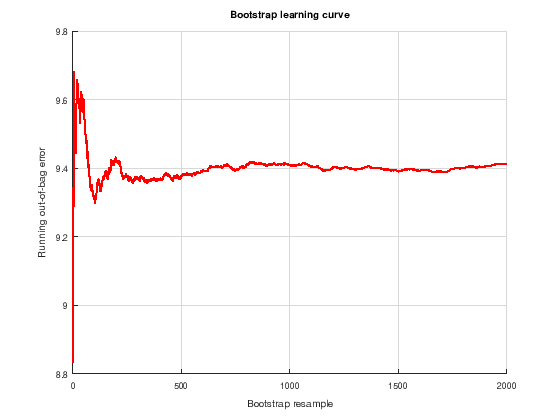

In [28]:
tic 
bootridge (outcomes, MAT_H.X, '*', 1999, 0.05, MAT_H.L, Deff);
toc
ridge_emm = ans;

In [29]:
ridge_emm

ridge_emm =

  scalar structure containing the fields:

    function = bootridge
    estimate =

     Columns 1 through 5:

           48.315      -52.984       88.913      -40.598       1.5833
           49.592      -50.564       88.218      -38.626       1.7297
           47.942      -50.986       91.924      -43.982       1.8683
           44.423      -51.096        90.02      -45.597        2.093
           43.994      -50.981        87.66      -43.665       1.8072
           36.413      -47.223       76.784      -40.371       1.8808

     Columns 6 through 10:

           5.0573      -1.1929       143.38       6.5702      -64.222
           4.4556      -1.0232       144.97       9.2213      -62.988
           4.3047      -1.0204       99.958       6.5515      -65.308
           3.7379     -0.79624       79.604       11.468      -65.215
           4.0774     -0.99585       99.792       5.4774      -65.119
           3.0949     -0.78227       82.117       8.9898      -62.598

     C

In [30]:
comparisons = [2 1; 4 3; 6 5]

comparisons =

            2            1
            4            3
            6            5



In [31]:
MAT_H_PAIRS = bootlm (outcomes(:,11), {genotype, condition}, 'model', 'full', ...
                     'display', 'off', 'contrasts', MAT_H.C, 'nboot', 0, 'dim', [1,2], 'posthoc', comparisons);

In [ ]:
tic
bootridge (outcomes, MAT_H_PAIRS.X, '*', 1999, 0.05, ...
          MAT_H_PAIRS.L, Deff);
toc
ridge_pairs = ans;


In [ ]:
ridge_pairs